In [52]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 



In [ ]:
import tensorflow as tf

data_dir = r"E:\AI Track\ITI\Deep learning\Day-2"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,      
    subset="training",
    seed=123,                   # Seed ensures train/val don't overlap
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary'         # 0 for 'no', 1 for 'yes'
)

# 2. Load Validation Set (20% of data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,                   # Must match training seed!
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary'
)

print("Classes:", train_ds.class_names)  # ['no', 'yes']

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.
Classes: ['no', 'yes']


In [ ]:
# Convert dataset batches to full NumPy arrays
train_images, train_labels = tuple(zip(*train_ds.unbatch().as_numpy_iterator()))
test_images, test_labels = tuple(zip(*val_ds.unbatch().as_numpy_iterator()))

# Convert tuples to NumPy array format
train_images = np.array(train_images)
train_labels = np.array(train_labels)
test_images = np.array(test_images)
test_labels = np.array(test_labels)

train_images, test_images = train_images / 255.0, test_images / 255.0

print(train_images.shape)
print(test_images.shape)

(203, 224, 224, 3)
(50, 224, 224, 3)


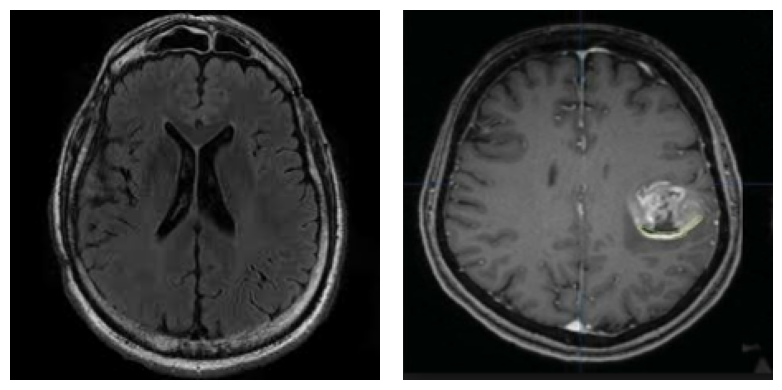

In [ ]:
class_names = ['no', 'yes']

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(train_images[0])
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(train_images[1])
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [57]:
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [59]:
history = model.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 351ms/step - accuracy: 0.6502 - loss: 2.2655 - val_accuracy: 0.3600 - val_loss: 3.3256
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step - accuracy: 0.5764 - loss: 1.2337 - val_accuracy: 0.6800 - val_loss: 0.7530
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.6158 - loss: 0.6277 - val_accuracy: 0.6800 - val_loss: 0.5958
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step - accuracy: 0.7586 - loss: 0.5181 - val_accuracy: 0.7800 - val_loss: 0.5644
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 0.7931 - loss: 0.4630 - val_accuracy: 0.8000 - val_loss: 0.5664
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.8325 - loss: 0.3915 - val_accuracy: 0.8400 - val_loss: 0.5446
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step - accuracy: 0.8719 - loss: 0.3075 - val_accuracy: 0.8400 - val_loss: 0.5182
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.9212 - loss: 0.2359 - val_accuracy: 0.8000 - val_loss:

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

2/2 - 0s - 54ms/step - accuracy: 0.9000 - loss: 0.5168

Test Accuracy: 90.00%
